# J02 — L'eau du sol : teneur en eau et état énergétique

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 2 : unités du potentiel, tensiomètres et charge hydraulique, loi de Jurin, étalonnage TDR et stock d'eau*

> Version **instructeur** : code complet et résultats.

## Mise en place

Les données sont dans le dossier `data/`. Convention du cours : $z$ positif vers le haut, origine à la surface du sol ;
charge hydraulique $H = h + z$ (cm) ; eau à 20 °C ($\rho_w = 998{,}2$ kg/m³, $g = 9{,}81$ m/s², $\sigma = 72{,}8$ mN/m).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.3})
RHO_W, G, SIGMA = 998.2, 9.81, 0.0728      # kg/m³, m/s², N/m (20 °C)

## Exercice 1 — Unités du potentiel et échelle pF  *(≈ 10 min)*

Le potentiel de l'eau s'exprime par unité de masse ($\psi$, J/kg), de volume ($\Psi = \rho_w \psi$, Pa) ou de poids
($h = \psi/g$, m ou cm de colonne d'eau). Rappels : $1$ kPa $= 1000/(\rho_w g)$ m $\approx 10{,}2$ cm ; $1$ bar $= 100$ kPa ;
$\mathrm{pF} = \log_{10}(|h|$ en cm$)$.

1. Écrire `convertir(valeur, de, vers)` qui convertit une valeur de potentiel entre les unités `"kPa"`, `"bar"`, `"cm"`, `"m"` et
   `"J/kg"` (passer par une unité pivot, par exemple le Pa).
2. Écrire `pF(h_cm)` (renvoyer `nan` si $h \ge 0$).
3. Construire la table des états remarquables pour $\Psi = -1, -10, -33, -100, -1500$ kPa : valeur en bar, cm, m, J/kg et pF.
4. Vérifier que pF $= \log_{10}(|\Psi|_{\mathrm{kPa}}) + 1{,}01$.

In [2]:
def convertir(valeur, de, vers):
    """Convertit un potentiel entre kPa, bar, cm, m, J/kg (pivot : Pa = J/m³)."""
    en_Pa = {"kPa": 1e3, "bar": 1e5, "m": RHO_W * G, "cm": RHO_W * G / 100, "J/kg": RHO_W}
    return np.asarray(valeur, dtype=float) * en_Pa[de] / en_Pa[vers]

def pF(h_cm):
    h_cm = np.asarray(h_cm, dtype=float)
    return np.where(h_cm < 0, np.log10(np.abs(h_cm)), np.nan)

etats = {"saturation proche": -1, "capacité au champ (sable)": -10, "capacité au champ": -33,
         "pF 3 (approx.)": -100, "point de flétrissement": -1500}
tab = pd.DataFrame({"Psi_kPa": list(etats.values())}, index=list(etats.keys()))
for u in ["bar", "cm", "m", "J/kg"]:
    tab[u] = convertir(tab["Psi_kPa"], "kPa", u)
tab["pF"] = pF(tab["cm"])
display(tab.round(3))

# 4. vérification de la règle rapide
print("pF - log10(|Psi| kPa) =", np.round(tab["pF"] - np.log10(-tab["Psi_kPa"]), 3).tolist())
print(f"Constante exacte : log10(1e3/(RHO_W*G)*100) = {np.log10(1e3/(RHO_W*G)*100):.3f}")

,Psi_kPa,bar,cm,m,J/kg,pF
saturation proche,-1,-0.01,-10.212,-0.102,-1.002,1.009
capacité au champ (sable),-10,-0.10,-102.121,-1.021,-10.018,2.009
capacité au champ,-33,-0.33,-336.998,-3.370,-33.060,2.528
pF 3 (approx.),-100,-1.00,-1021.206,-10.212,-100.180,3.009
point de flétrissement,-1500,-15.00,-15318.092,-153.181,-1502.705,4.185


pF - log10(|Psi| kPa) = [1.009, 1.009, 1.009, 1.009, 1.009]
Constante exacte : log10(1e3/(RHO_W*G)*100) = 1.009


**Commentaire (instructeur).** La constante 1,009 relie pF et log₁₀|Ψ| en kPa ; le point de flétrissement (−1500 kPa) vaut −15 320 cm, soit pF 4,19 (arrondi 4,2).
La conversion kPa → J/kg est quasi identique (facteur 1,002) : les deux unités sont interchangeables à 0,2 % près.

## Exercice 2 — Tensiomètres : charge hydraulique et sens de l'écoulement  *(≈ 20 min)*

`data/J02_tensiometres.csv` : six tensiomètres à jauge à vide installés à 15, 30, 45, 60, 90 et 120 cm de profondeur dans un loam.
Pour chaque tensiomètre : `lecture_kPa` (succion $S$ lue par la jauge, positive) et `L_col_cm` (hauteur de la jauge au-dessus
de la bougie). Deux dates : après une pluie, puis après sept jours sans pluie.

1. Calculer la charge de pression à la bougie $h = -10{,}2\,S + L$ (cm), la cote $z = -$profondeur et la charge hydraulique $H = h + z$.
2. Tracer $h(z)$ et $H(z)$ pour les deux dates (profondeur en ordonnée).
3. Entre tensiomètres voisins, calculer le gradient $\Delta H/\Delta z = (H_{\text{haut}} - H_{\text{bas}})/(z_{\text{haut}} - z_{\text{bas}})$
   et en déduire le sens du flux (gradient $> 0$ : vers le bas ; $< 0$ : vers le haut) et son intensité relative.
4. Localiser, à la seconde date, le plan de flux nul (changement de signe du gradient : interpoler la profondeur où $\Delta H/\Delta z = 0$).

,date,profondeur_cm,L_col_cm,lecture_kPa,h_cm,z_cm,H_cm
0,2025-06-03 (après pluie),15,35,7.2,-38.5,-15,-53.5
1,2025-06-03 (après pluie),30,50,8.5,-36.8,-30,-66.8
2,2025-06-03 (après pluie),45,65,10.1,-38.1,-45,-83.1
3,2025-06-03 (après pluie),60,80,11.9,-41.5,-60,-101.5
4,2025-06-03 (après pluie),90,110,14.9,-42.2,-90,-132.2
5,2025-06-03 (après pluie),120,140,18.4,-47.9,-120,-167.9
6,2025-06-10 (après 7 j secs),15,35,47.7,-452.1,-15,-467.1
7,2025-06-10 (après 7 j secs),30,50,34.4,-301.3,-30,-331.3
8,2025-06-10 (après 7 j secs),45,65,24.3,-183.2,-45,-228.2
9,2025-06-10 (après 7 j secs),60,80,19.5,-119.1,-60,-179.1


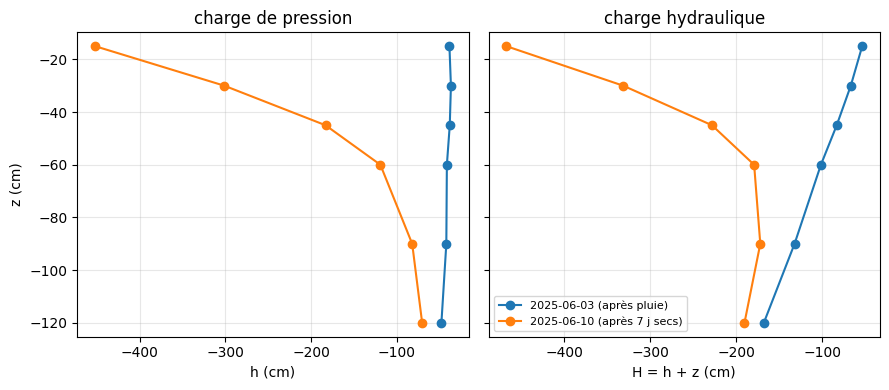

--- 2025-06-03 (après pluie)


,intervalle,z_milieu,dH_dz,sens
0,15-30 cm,-22.5,0.89,vers le bas
1,30-45 cm,-37.5,1.09,vers le bas
2,45-60 cm,-52.5,1.23,vers le bas
3,60-90 cm,-75.0,1.02,vers le bas
4,90-120 cm,-105.0,1.19,vers le bas


--- 2025-06-10 (après 7 j secs)


,intervalle,z_milieu,dH_dz,sens
0,15-30 cm,-22.5,-9.05,vers le haut
1,30-45 cm,-37.5,-6.88,vers le haut
2,45-60 cm,-52.5,-3.27,vers le haut
3,60-90 cm,-75.0,-0.24,vers le haut
4,90-120 cm,-105.0,0.61,vers le bas


Plan de flux nul (2e date) vers z ≈ -75 cm : évaporation au-dessus, drainage en dessous.


In [3]:
tens = pd.read_csv("data/J02_tensiometres.csv")
KPA_CM = 1e3 / (RHO_W * G) * 100      # cm de colonne d'eau par kPa (10,21)

# 1. charge de pression à la bougie, cote, charge hydraulique
tens["h_cm"] = -tens["lecture_kPa"] * KPA_CM + tens["L_col_cm"]
tens["z_cm"] = -tens["profondeur_cm"]
tens["H_cm"] = tens["h_cm"] + tens["z_cm"]
display(tens.round(1))

# 2. profils h(z) et H(z)
fig, ax = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for date, g in tens.groupby("date"):
    ax[0].plot(g["h_cm"], g["z_cm"], "o-", label=date)
    ax[1].plot(g["H_cm"], g["z_cm"], "o-", label=date)
ax[0].set_xlabel("h (cm)"); ax[0].set_ylabel("z (cm)"); ax[0].set_title("charge de pression")
ax[1].set_xlabel("H = h + z (cm)"); ax[1].set_title("charge hydraulique"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# 3. gradients entre tensiomètres voisins
def gradients(g):
    g = g.sort_values("profondeur_cm").reset_index(drop=True)
    rows = []
    for i in range(len(g) - 1):
        dH = g.loc[i, "H_cm"] - g.loc[i + 1, "H_cm"]        # haut - bas
        dz = g.loc[i, "z_cm"] - g.loc[i + 1, "z_cm"]        # > 0
        grad = dH / dz
        rows.append(dict(intervalle=f"{g.loc[i,'profondeur_cm']:.0f}-{g.loc[i+1,'profondeur_cm']:.0f} cm",
                         z_milieu=(g.loc[i, "z_cm"] + g.loc[i + 1, "z_cm"]) / 2, dH_dz=grad,
                         sens="vers le bas" if grad > 0 else "vers le haut"))
    return pd.DataFrame(rows)

grads = {date: gradients(g) for date, g in tens.groupby("date")}
for date, gr in grads.items():
    print(f"--- {date}"); display(gr.round(2))

# 4. plan de flux nul (2e date) : profondeur où le gradient change de signe
gr = grads[sorted(grads)[1]]
sgn = np.sign(gr["dH_dz"].to_numpy())
idx = np.where(np.diff(sgn) != 0)[0]
if len(idx):
    i = idx[0]
    z0 = np.interp(0, gr.loc[[i + 1, i], "dH_dz"], gr.loc[[i + 1, i], "z_milieu"])   # interpolation linéaire
    print(f"Plan de flux nul (2e date) vers z ≈ {z0:.0f} cm : évaporation au-dessus, drainage en dessous.")
else:
    print("Pas de changement de signe : flux de même sens sur tout le profil.")

**Commentaire (instructeur).** Après la pluie, $h$ est presque uniforme (−35 à −45 cm) : le gradient de $H$ vaut ≈ 1 partout, l'eau draine vers le bas sous
gradient unitaire. Après sept jours secs, $h$ chute à −450 cm en surface : le gradient est négatif (flux ascendant, évaporation)
jusque vers 75–90 cm, puis redevient positif (drainage) : c'est le plan de flux nul. Noter que la correction de colonne
($+L$) change $h$ de 35 à 140 cm : l'oublier fausse complètement les gradients.

## Exercice 3 — Loi de Jurin et distribution des tailles de pores  *(≈ 15 min)*

La loi de Jurin relie la charge de pression $h$ au rayon du plus gros pore encore plein d'eau :
$|h| = 2\sigma\cos\gamma/(\rho_w g\, r)$, soit $r\,[\mathrm{cm}] \approx 0{,}149/|h|\,[\mathrm{cm}]$ à 20 °C ($\gamma = 0$).

1. Écrire `rayon(h_cm, T=20)` (rayon équivalent en µm) et `h_de_rayon(r_um, T=20)` (cm), avec $\sigma(T)$ interpolée
   dans la table : 0 °C : 75,6 ; 10 °C : 74,2 ; 20 °C : 72,8 ; 30 °C : 71,2 ; 40 °C : 69,6 mN/m. Vérifier le facteur 0,149 à 20 °C
   et calculer la remontée capillaire pour $r$ = 1, 10, 100 et 1000 µm.
2. `data/J02_retention.csv` : courbes $\theta(h)$ (drainage) d'un sable et d'un loam. Calculer $r$ pour chaque point, puis la
   densité de distribution des tailles de pores $f(r) = \mathrm{d}\theta/\mathrm{d}\log_{10} r$ (`np.gradient`). Tracer $f$ en fonction de $r$ (échelle log).
3. Pour chaque sol : rayon modal, fraction du volume poral ($\theta_s - \theta_r$, avec $\theta_r = \theta(-10^5$ cm$)$)
   correspondant aux macropores ($r > 30$ µm) et aux pores $< 0{,}1$ µm.

facteur 2σ/(ρw g) à 20 °C = 0.1487 cm²  (0,149 attendu)
r =     1 µm : remontée capillaire =   1486.9 cm
r =    10 µm : remontée capillaire =    148.7 cm
r =   100 µm : remontée capillaire =     14.9 cm
r =  1000 µm : remontée capillaire =      1.5 cm


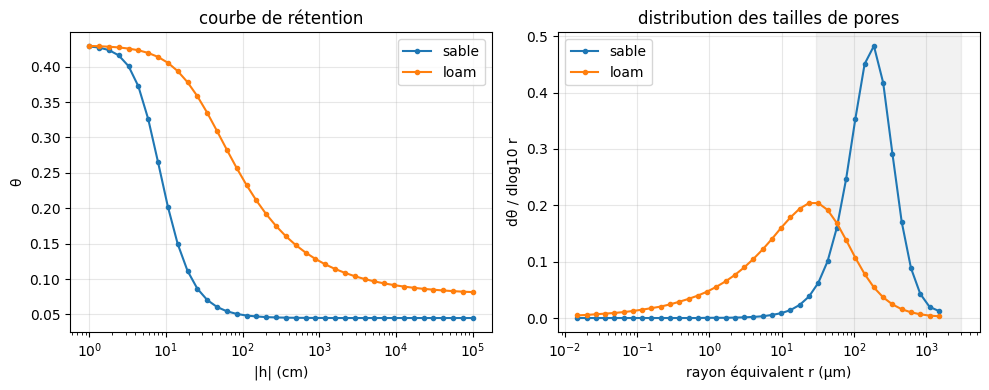

,theta_s,theta_r,r_modal_um,h_modal_cm,frac_macropores,frac_inf_0p1um
sable,0.429,0.045,188.284,-7.897,0.963,0.00
loam,0.429,0.082,23.845,-62.355,0.363,0.02


In [4]:
T_tab = np.array([0, 10, 20, 30, 40]); sig_tab = np.array([75.6, 74.2, 72.8, 71.2, 69.6]) * 1e-3   # N/m

def rayon(h_cm, T=20):
    """Rayon de pore équivalent (µm) pour une charge de pression h (cm), angle de contact nul."""
    sigma = np.interp(T, T_tab, sig_tab)
    r_m = 2 * sigma / (RHO_W * G * np.abs(np.asarray(h_cm, float)) / 100)   # |h| en m
    return r_m * 1e6

def h_de_rayon(r_um, T=20):
    """Charge de pression (cm, négative) à laquelle un pore de rayon r (µm) se vide."""
    sigma = np.interp(T, T_tab, sig_tab)
    return -2 * sigma / (RHO_W * G * np.asarray(r_um, float) * 1e-6) * 100

print(f"facteur 2σ/(ρw g) à 20 °C = {2*0.0728/(RHO_W*G)*1e4:.4f} cm²  (0,149 attendu)")
for r in [1, 10, 100, 1000]:
    print(f"r = {r:5d} µm : remontée capillaire = {-h_de_rayon(r):8.1f} cm")

# 2. distribution des tailles de pores
ret = pd.read_csv("data/J02_retention.csv")
ret["r_um"] = rayon(ret["h_cm"])
logr = np.log10(ret["r_um"].to_numpy())
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
res = {}
for sol in ["sable", "loam"]:
    th = ret[f"theta_{sol}"].to_numpy()
    f = np.gradient(th, logr)                       # dθ/dlog10 r (> 0)
    ret[f"f_{sol}"] = f
    ax[0].semilogx(-ret["h_cm"], th, "o-", ms=3, label=sol)
    ax[1].semilogx(ret["r_um"], f, "o-", ms=3, label=sol)
    # 3. rayon modal et fractions
    r_mode = ret.loc[np.argmax(f), "r_um"]
    ts, tr = th[0], th[-1]
    th_30 = np.interp(np.log10(30), logr[::-1], th[::-1])       # θ au rayon 30 µm (logr décroît avec la ligne)
    th_01 = np.interp(np.log10(0.1), logr[::-1], th[::-1])
    res[sol] = dict(theta_s=ts, theta_r=tr, r_modal_um=r_mode, h_modal_cm=h_de_rayon(r_mode),
                    frac_macropores=max(0, (ts - th_30) / (ts - tr)), frac_inf_0p1um=max(0, (th_01 - tr) / (ts - tr)))
ax[0].set_xlabel("|h| (cm)"); ax[0].set_ylabel("θ"); ax[0].legend(); ax[0].set_title("courbe de rétention")
ax[1].set_xlabel("rayon équivalent r (µm)"); ax[1].set_ylabel("dθ / dlog10 r"); ax[1].legend()
ax[1].axvspan(30, 3000, alpha=0.1, color="gray"); ax[1].set_title("distribution des tailles de pores")
plt.tight_layout(); plt.show()
display(pd.DataFrame(res).T.round(3))

**Commentaire (instructeur).** Le sable a un pic étroit vers 200 µm (|h| ≈ 7 cm) : plus de 90 % de son volume poral est constitué de macropores qui se vident
dès les premiers centimètres de succion. Le loam a un mode vers 25–30 µm (|h| ≈ 50–60 cm ; analytiquement $|h| = m^{-1/n}/lpha$)
mais une distribution très étalée : ~35 % du volume poral dans les macropores et quelques pour cent de pores < 0,1 µm, dont
l'eau (pF > 4,2) est inaccessible aux plantes.
Aux très faibles rayons (< 0,05 µm), le « rayon » n'a plus de sens géométrique : la rétention est due à l'adsorption.

## Exercice 4 — Étalonnage TDR et stock d'eau d'un profil  *(≈ 15 min)*

1. `data/J02_tdr_etalonnage.csv` : 30 couples ($\varepsilon_a$, $\theta_{\text{grav}}$) mesurés sur un loam riche en matière
   organique. Ajuster un polynôme de degré 3 $\theta = a_0 + a_1\varepsilon_a + a_2\varepsilon_a^2 + a_3\varepsilon_a^3$
   (`np.polyfit`) et le comparer à l'équation de Topp et al. (1980) :
   $\theta = -5{,}3\times10^{-2} + 2{,}92\times10^{-2}\varepsilon_a - 5{,}5\times10^{-4}\varepsilon_a^2 + 4{,}3\times10^{-6}\varepsilon_a^3$.
   Calculer le RMSE et le biais moyen de chaque étalonnage par rapport aux mesures gravimétriques.
2. `data/J02_tdr_profils.csv` : $\varepsilon_a$ mesurée à 8 profondeurs (10 à 100 cm) à trois dates ; 32 mm de pluie sont tombés
   entre les dates 2 et 3. Convertir en $\theta$ avec les deux étalonnages, tracer les profils.
3. Calculer le stock d'eau $W$ (mm) sur 0–100 cm par la méthode des trapèzes (`np.trapezoid`), en supposant $\theta$ constant entre
   la surface et la première sonde. Comparer les deux étalonnages et commenter la variation de stock entre les dates.

coefficients (a3, a2, a1, a0) : [ 6.0000e-06 -6.8000e-04  3.2567e-02 -4.0562e-02]
Topp (1980)     : RMSE = 0.041   biais = -0.039
polynôme local  : RMSE = 0.011   biais = +0.000


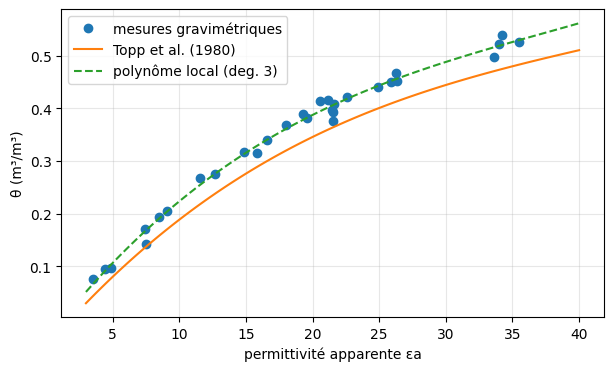

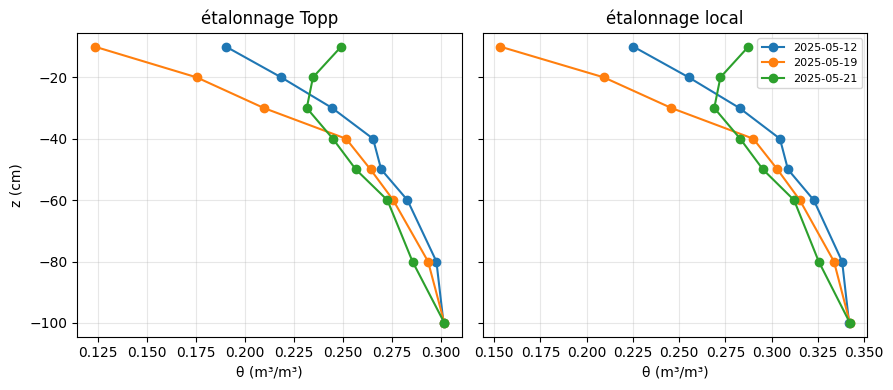

,Topp,local,écart local - Topp
2025-05-12,260.4,299.1,38.7
2025-05-19,238.7,276.1,37.4
2025-05-21,262.3,301.2,39.0


Variation de stock (étalonnage local) entre dates (mm) : [-23.   25.1]
Pluie entre les dates 2 et 3 : 32 mm -> 7 mm non stockés dans 0-100 cm (évaporation, interception, drainage)
Même variation avec l'étalonnage de Topp (mm) : [-21.7  23.5] -> le biais s'élimine par différence


In [5]:
def topp(eps):
    return -5.3e-2 + 2.92e-2 * eps - 5.5e-4 * eps**2 + 4.3e-6 * eps**3

cal = pd.read_csv("data/J02_tdr_etalonnage.csv")
eps, th = cal["eps_a"].to_numpy(), cal["theta_grav"].to_numpy()

# 1. polynôme local de degré 3 et comparaison à Topp
coef = np.polyfit(eps, th, 3)
poly_local = np.poly1d(coef)
print("coefficients (a3, a2, a1, a0) :", np.round(coef, 6))
for nom, f in [("Topp (1980)", topp), ("polynôme local", poly_local)]:
    err = f(eps) - th
    print(f"{nom:15s} : RMSE = {np.sqrt(np.mean(err**2)):.3f}   biais = {err.mean():+.3f}")
ee = np.linspace(3, 40, 100)
fig, ax = plt.subplots()
ax.plot(eps, th, "o", label="mesures gravimétriques")
ax.plot(ee, topp(ee), label="Topp et al. (1980)")
ax.plot(ee, poly_local(ee), "--", label="polynôme local (deg. 3)")
ax.set_xlabel("permittivité apparente εa"); ax.set_ylabel("θ (m³/m³)"); ax.legend(); plt.show()

# 2. profils θ(z) avec les deux étalonnages
prof = pd.read_csv("data/J02_tdr_profils.csv")
dates = [c for c in prof.columns if c != "profondeur_cm"]
z = prof["profondeur_cm"].to_numpy()
fig, ax = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for a, (nom, f) in zip(ax, [("Topp", topp), ("local", poly_local)]):
    for d in dates:
        a.plot(f(prof[d]), -z, "o-", label=d)
    a.set_title(f"étalonnage {nom}"); a.set_xlabel("θ (m³/m³)")
ax[0].set_ylabel("z (cm)"); ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()

# 3. stock d'eau 0-100 cm (mm) par trapèzes, θ constant entre 0 et 10 cm
def stock_mm(z_cm, theta):
    zz = np.concatenate([[0.0], z_cm]); tt = np.concatenate([[theta[0]], theta])
    return np.trapezoid(tt, zz) * 10          # cm -> mm

W = pd.DataFrame({nom: [stock_mm(z, np.asarray(f(prof[d]))) for d in dates] for nom, f in [("Topp", topp), ("local", poly_local)]},
                 index=dates)
W["écart local - Topp"] = W["local"] - W["Topp"]
display(W.round(1))
dW = W["local"].diff()
print("Variation de stock (étalonnage local) entre dates (mm) :", np.round(dW.to_numpy()[1:], 1))
print("Pluie entre les dates 2 et 3 : 32 mm ->", f"{32 - dW.iloc[-1]:.0f} mm non stockés dans 0-100 cm (évaporation, interception, drainage)")
dW_topp = W["Topp"].diff()
print("Même variation avec l'étalonnage de Topp (mm) :", np.round(dW_topp.to_numpy()[1:], 1), "-> le biais s'élimine par différence")

**Commentaire (instructeur).** L'équation de Topp sous-estime θ de ~0,04 pour ce sol organique (biais négatif) ; le polynôme local ramène le RMSE à ~0,012.
Sur le stock, l'écart entre étalonnages atteint 30–40 mm sur 1 m : le biais se cumule sur l'épaisseur. En revanche la
*variation* de stock entre dates est presque la même avec les deux étalonnages (le biais s'élimine par différence). Entre les
dates 2 et 3, la pluie de 32 mm n'apparaît qu'en partie dans le stock : le reste est évaporé, intercepté ou drainé.

## Exercice 5 — Bonus — potentiel osmotique  *(≈ facultatif)*

Calculer le potentiel osmotique de solutions de NaCl de 1 à 500 mmol/L par la loi de van 't Hoff
$\Psi_o = -i\,c\,R\,T$ ($i = 2$, $c$ en mol/m³, $R = 8{,}314$ J/(mol K), $T = 293$ K), l'exprimer en kPa et en m d'eau,
puis comparer à la règle empirique $\Psi_o$ [kPa] $\approx -36\,\mathrm{CE}$ [dS/m] avec $\mathrm{CE} \approx 0{,}107\,c^{0{,}98}$ dS/m ($c$ en mmol/L).

In [6]:
c_mmol = np.array([1, 5, 10, 50, 100, 500])
R, T = 8.314, 293.15
psi_vh = -2 * (c_mmol * 1e-3 * 1e3) * R * T / 1e3          # kPa (c en mol/m³ = mmol/L)
CE = 0.107 * c_mmol**0.98
psi_ce = -36 * CE
tab = pd.DataFrame({"c (mmol/L)": c_mmol, "CE (dS/m)": CE, "Psi_o van 't Hoff (kPa)": psi_vh,
                    "Psi_o (m d'eau)": psi_vh * 1e3 / (RHO_W * G), "Psi_o = -36 CE (kPa)": psi_ce})
display(tab.round(2))
print("Eau de mer (~0,6 M) : Psi_o ≈", round(-2 * 600 * R * T / 1e3), "kPa ; les racines ne peuvent pas l'absorber.")

,c (mmol/L),CE (dS/m),Psi_o van 't Hoff (kPa),Psi_o (m d'eau),Psi_o = -36 CE (kPa)
0,1,0.11,-4.87,-0.50,-3.85
1,5,0.52,-24.37,-2.49,-18.65
2,10,1.02,-48.74,-4.98,-36.79
3,50,4.95,-243.72,-24.89,-178.11
4,100,9.76,-487.45,-49.78,-351.31
5,500,47.25,-2437.25,-248.89,-1700.89


Eau de mer (~0,6 M) : Psi_o ≈ -2925 kPa ; les racines ne peuvent pas l'absorber.


**Commentaire (instructeur).** La règle −36·CE et van 't Hoff concordent à ~10 % jusqu'à 100 mmol/L ; au-delà, la solution n'est plus idéale (coefficient osmotique < 1).

## Pour aller plus loin

* Exercice 2 : estimer le flux réel entre tensiomètres en supposant $K(h)$ de Mualem–van Genuchten pour le loam (Jour 5).
* Exercice 3 : refaire le calcul avec un angle de contact de 60° (sol hydrophobe) ; que devient la distribution ?
* Exercice 4 : propager une incertitude de ±0,5 sur $\varepsilon_a$ (Monte-Carlo) jusqu'au stock d'eau.